<a href="https://colab.research.google.com/github/nishthadighe-bit/Data--Engineering-Practicals/blob/main/Practical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Data After Outlier Removal ---
   Age  Marks  Attendance  Constant
0   20     75          85         1
1   21     80          88         1
2   22     85          90         1
3   23     90          92         1
4   24     95          94         1

--- Selected Features ---
['Age', 'Marks', 'Attendance']

--- Statistical Summary ---
             Age      Marks  Attendance
count   5.000000   5.000000     5.00000
mean   22.000000  85.000000    89.80000
std     1.581139   7.905694     3.49285
min    20.000000  75.000000    85.00000
25%    21.000000  80.000000    88.00000
50%    22.000000  85.000000    90.00000
75%    23.000000  90.000000    92.00000
max    24.000000  95.000000    94.00000

Correlation Matrix:
                  Age     Marks  Attendance
Age         1.000000  1.000000    0.995893
Marks       1.000000  1.000000    0.995893
Attendance  0.995893  0.995893    1.000000


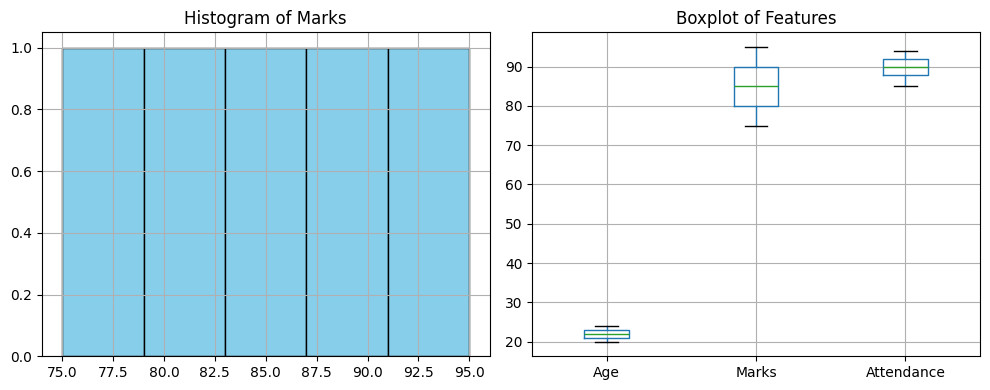

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

# Sample Dataset with Outliers & Constant Feature
data = {
    'Age': [20, 21, 22, 23, 24, 100],   # 100 is an outlier (noise)
    'Marks': [75, 80, 85, 90, 95, 20],
    'Attendance': [85, 88, 90, 92, 94, 50],
    'Constant': [1, 1, 1, 1, 1, 1]      # Low variance/constant feature
}

df = pd.DataFrame(data)

# 1. Noise Elimination (IQR Outlier Removal on Age)
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['Age'] >= lower) & (df['Age'] <= upper)].copy()

print("--- Data After Outlier Removal ---")
print(df_clean)

# 2. Feature Selection (Removing zero-variance features)
selector = VarianceThreshold(threshold=0.0)
selector.fit(df_clean)
selected_columns = df_clean.columns[selector.get_support()]

df_selected = df_clean[selected_columns]

print("\n--- Selected Features ---")
print(df_selected.columns.tolist())

# 3. Exploratory Data Analysis (EDA)
print("\n--- Statistical Summary ---")
print(df_selected.describe())
print("\nCorrelation Matrix:\n", df_selected.corr())

# Visualizations
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df_selected['Marks'].hist(bins=5, color='skyblue', edgecolor='black')
plt.title("Histogram of Marks")

plt.subplot(1, 2, 2)
df_selected.boxplot(column=['Age', 'Marks', 'Attendance'])
plt.title("Boxplot of Features")

plt.tight_layout()
plt.show()